In [1]:
pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow


In [3]:
import tensorflow as tf
print(tf.__version__)



2.15.1


In [4]:
pip install opencv-python


Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install mediapipe

In [6]:
pip install scikit-learn

In [7]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [8]:
!pip install tensorflowjs

In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [2]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [3]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR-CONVERSION BGR-to-RGB
    image.flags.writeable = False                  # Convert image to not-writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Convert image to writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR-COVERSION RGB-to-BGR
    return image, results

In [4]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [5]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [17]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [18]:
draw_landmarks(frame, results)

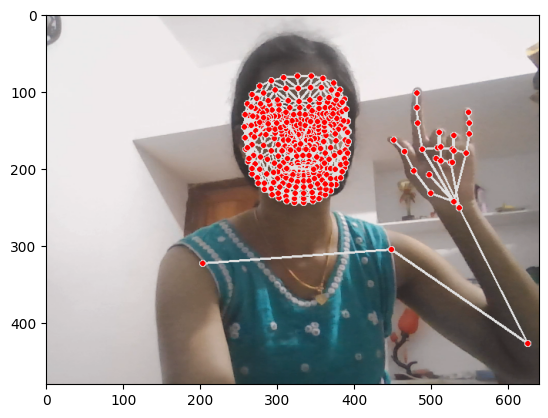

In [19]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [6]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [7]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['hello', 'iloveyou', 'thanks'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 30


In [8]:
signs = ['hello','iloveyou','thanks']

parent_folder = 'MP_Data'

if not os.path.exists(parent_folder):
    os.mkdir(parent_folder)
    for sign in signs:
        sign_folder = os.path.join(parent_folder, sign)
        os.mkdir(sign_folder)
        for i in range(30):
            subfolder = os.path.join(sign_folder, str(i))
            os.mkdir(subfolder)

In [24]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

In [13]:
import numpy as np
import os
from scipy.spatial.transform import Rotation as R
import random

def augment_keypoints(keypoints, sequence_length=30):
    """
    Apply various augmentations to keypoint sequences
    Returns a list of augmented versions of the input sequence
    """
    augmented_sequences = []
    
    # Original sequence
    augmented_sequences.append(keypoints)
    
    # 1. Temporal Augmentations (speed variations)
    for factor in [0.8, 1.2]:  # Slow down and speed up
        temp_seq = temporal_interpolation(keypoints, factor)
        augmented_sequences.append(temp_seq)
    
    # 2. Spatial Augmentations
    for _ in range(2):  # Create 2 spatial variations
        # Random rotation (between -15 and 15 degrees)
        angle = np.random.uniform(-15, 15)
        rotated_seq = rotate_keypoints(keypoints, angle)
        
        # Random scaling (between 0.8 and 1.2)
        scale = np.random.uniform(0.8, 1.2)
        scaled_seq = scale_keypoints(rotated_seq, scale)
        
        # Random translation (between -0.1 and 0.1)
        translation = np.random.uniform(-0.1, 0.1, size=3)
        translated_seq = translate_keypoints(scaled_seq, translation)
        
        augmented_sequences.append(translated_seq)
    
    # 3. Noise Injection
    for _ in range(2):  # Create 2 noisy versions
        noisy_seq = add_noise(keypoints, noise_level=0.01)
        augmented_sequences.append(noisy_seq)
    
    # Ensure all sequences have correct length
    final_sequences = []
    for seq in augmented_sequences:
        if len(seq) < sequence_length:
            # Pad with last frame if shorter
            last_frame = seq[-1]
            padding = np.tile(last_frame, (sequence_length - len(seq), 1))
            padded_seq = np.concatenate([seq, padding])
            final_sequences.append(padded_seq)
        elif len(seq) > sequence_length:
            # Trim if longer
            final_sequences.append(seq[:sequence_length])
        else:
            final_sequences.append(seq)
    
    return final_sequences

def temporal_interpolation(sequence, factor):
    """Change speed of the sequence"""
    orig_length = len(sequence)
    new_length = int(orig_length * factor)
    
    # Create interpolation indices
    orig_indices = np.arange(orig_length)
    new_indices = np.linspace(0, orig_length-1, new_length)
    
    # Interpolate
    interpolated = np.array([
        np.interp(new_indices, orig_indices, sequence[:, i]) 
        for i in range(sequence.shape[1])
    ]).T
    
    return interpolated

def rotate_keypoints(sequence, angle_degrees):
    """Rotate all keypoints around vertical (Y) axis"""
    angle_rad = np.radians(angle_degrees)
    rot = R.from_euler('y', angle_rad).as_matrix()
    
    rotated = sequence.copy()
    for i in range(len(sequence)):
        # Get xyz coordinates (assuming they're in order x,y,z,x,y,z,...)
        xyz = sequence[i].reshape(-1, 3)
        rotated_xyz = np.dot(xyz, rot.T)
        rotated[i] = rotated_xyz.reshape(-1)
    
    return rotated

def scale_keypoints(sequence, scale_factor):
    """Scale all keypoints uniformly"""
    scaled = sequence.copy()
    # Find xyz components (assuming they're in order x,y,z,x,y,z,...)
    xyz_indices = np.arange(0, sequence.shape[1], 3)
    for i in xyz_indices:
        scaled[:, i:i+3] *= scale_factor
    return scaled

def translate_keypoints(sequence, translation):
    """Translate all keypoints"""
    translated = sequence.copy()
    # Find xyz components (assuming they're in order x,y,z,x,y,z,...)
    xyz_indices = np.arange(0, sequence.shape[1], 3)
    for i in xyz_indices:
        translated[:, i:i+3] += translation
    return translated

def add_noise(sequence, noise_level=0.01):
    """Add Gaussian noise to keypoints"""
    noise = np.random.normal(0, noise_level, sequence.shape)
    return sequence + noise

def augment_all_data(data_path, actions, no_sequences, sequence_length):
    """Apply augmentation to all data in the dataset"""
    for action in actions:
        for sequence in range(no_sequences):
            sequence_path = os.path.join(data_path, action, str(sequence))
            
            # Load original sequence
            original_frames = []
            for frame_num in range(sequence_length):
                frame_file = os.path.join(sequence_path, f"{frame_num}.npy")
                if os.path.exists(frame_file):
                    original_frames.append(np.load(frame_file))
            
            if len(original_frames) != sequence_length:
                continue
                
            original_sequence = np.array(original_frames)
            
            # Generate augmentations
            augmented_sequences = augment_keypoints(original_sequence, sequence_length)
            
            # Save augmentations as new sequences
            for aug_idx, aug_sequence in enumerate(augmented_sequences[1:], 1):  # Skip original
                new_seq_num = no_sequences + (sequence * (len(augmented_sequences)-1)) + (aug_idx-1)
                new_seq_path = os.path.join(data_path, action, str(new_seq_num))
                os.makedirs(new_seq_path, exist_ok=True)
                
                for frame_num in range(sequence_length):
                    frame_file = os.path.join(new_seq_path, f"{frame_num}.npy")
                    np.save(frame_file, aug_sequence[frame_num])
    
    print("Data augmentation complete!")

# Usage
DATA_PATH = 'MP_Data'
actions = ['hello', 'iloveyou', 'thanks']
no_sequences = 30
sequence_length = 30

augment_all_data(DATA_PATH, actions, no_sequences, sequence_length)

Data augmentation complete!


In [14]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [16]:
label_map = {label:num for num, label in enumerate(actions)}

In [17]:
label_map

{'hello': 0, 'iloveyou': 1, 'thanks': 2}

In [18]:
import os
print(os.listdir('MP_Data/hello/26'))


['0.npy', '1.npy', '10.npy', '11.npy', '12.npy', '13.npy', '14.npy', '15.npy', '16.npy', '17.npy', '18.npy', '19.npy', '2.npy', '20.npy', '21.npy', '22.npy', '23.npy', '24.npy', '25.npy', '26.npy', '27.npy', '28.npy', '29.npy', '3.npy', '4.npy', '5.npy', '6.npy', '7.npy', '8.npy', '9.npy']


In [19]:
import os
import numpy as np

sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)  # Path to the action folder
    if os.path.isdir(action_path):  # Check if the directory exists
        for sequence in os.listdir(action_path):
            sequence_path = os.path.join(action_path, sequence)
            if os.path.isdir(sequence_path):  # Ensure it's a sequence folder
                window = []
                for frame_num in range(sequence_length):
                    frame_file = os.path.join(sequence_path, "{}.npy".format(frame_num))
                    if os.path.exists(frame_file):  # Check if the file exists
                        res = np.load(frame_file)
                        window.append(res)
                    else:
                        print(f"Warning: {frame_file} not found.")  # Inform if file is missing
                        continue  # Skip missing frames
                if len(window) == sequence_length:  # Only append full windows
                    sequences.append(window)
                    labels.append(label_map[action])
            else:
                print(f"Skipping invalid sequence folder: {sequence_path}")
    else:
        print(f"Action folder {action} not found.")


In [20]:
X = np.array(sequences)

In [21]:
y = to_categorical(labels).astype(int)

In [22]:
# Stratified split (maintains class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # This ensures balanced classes in both sets
)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Dropout
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.regularizers import l2

In [24]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)
#While training access tensorboard
#tensorboard --logdir=.

In [26]:
# 2. Build and train the model
num_classes = len(actions)

model = Sequential([
    LSTM(64, return_sequences=True, activation='tanh', 
         input_shape=(30, 1662), kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    LSTM(128, return_sequences=True, activation='tanh', kernel_regularizer=l2(0.01)),
    Dropout(0.4),
    LSTM(64, return_sequences=False, activation='tanh', kernel_regularizer=l2(0.01)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(num_classes, activation='softmax')
])

In [31]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Best practice implementation
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='accuracy', patience=20, mode='max', restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=10, verbose=1)
]

In [32]:
# Start with 500 but will stop early if needed
history = model.fit(X, y, 
                   epochs=500,
                   batch_size=32,
                   callbacks=callbacks,
                   verbose=1)

print(f"Training stopped after {len(history.history['loss'])} epochs")
print(f"Best accuracy: {max(history.history['accuracy']):.2f}")

Epoch 1/500


20/20 [==============================] - 10s 68ms/step - loss: 7.1850 - accuracy: 0.4730 - lr: 0.0010
Epoch 2/500
20/20 [==============================] - 1s 52ms/step - loss: 4.0194 - accuracy: 0.6444 - lr: 0.0010
Epoch 3/500
20/20 [==============================] - 1s 52ms/step - loss: 2.6368 - accuracy: 0.6635 - lr: 0.0010
Epoch 4/500
20/20 [==============================] - 1s 55ms/step - loss: 1.9987 - accuracy: 0.6921 - lr: 0.0010
Epoch 5/500
20/20 [==============================] - 1s 52ms/step - loss: 1.6215 - accuracy: 0.7016 - lr: 0.0010
Epoch 6/500
20/20 [==============================] - 1s 53ms/step - loss: 1.4821 - accuracy: 0.6460 - lr: 0.0010
Epoch 7/500
20/20 [==============================] - 1s 63ms/step - loss: 1.2282 - accuracy: 0.6603 - lr: 0.0010
Epoch 8/500
20/20 [==============================] - 1s 52ms/step - loss: 1.1883 - accuracy: 0.6587 - lr: 0.0010
Epoch 9/500
20/20 [==============================] - 1s 52ms/step - loss: 1.0217 - accuracy: 

In [ ]:

from sklearn.metrics import accuracy_score
# 3. Calculate training accuracy
y_train_pred = model.predict(X_train)
y_train_pred_classes = np.argmax(y_train_pred, axis=1)
y_train_true = np.argmax(y_train, axis=1)

train_accuracy = accuracy_score(y_train_true, y_train_pred_classes)
print(f"Training Accuracy: {train_accuracy:.4f}")

# For detailed metrics:
from sklearn.metrics import classification_report
print(classification_report(y_train_true, y_train_pred_classes, target_names=actions))

16/16 [==============================] - 9s 98ms/step
Training Accuracy: 0.8591
              precision    recall  f1-score   support

       hello       0.81      0.88      0.84       168
    iloveyou       0.85      0.70      0.77       168
      thanks       0.91      1.00      0.95       168

    accuracy                           0.86       504
   macro avg       0.86      0.86      0.86       504
weighted avg       0.86      0.86      0.86       504



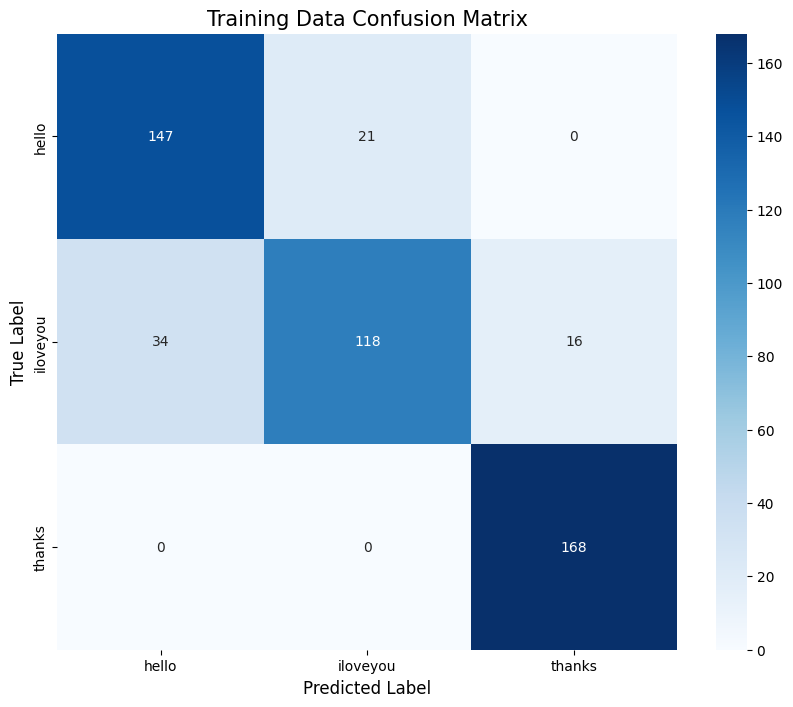

In [19]:
# Compute confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
conf_mat_train = confusion_matrix(y_train_true, y_train_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=actions, yticklabels=actions)
plt.title('Training Data Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [33]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 30, 64)            442112    
                                                                 
 dropout_3 (Dropout)         (None, 30, 64)            0         
                                                                 
 lstm_4 (LSTM)               (None, 30, 128)           98816     
                                                                 
 dropout_4 (Dropout)         (None, 30, 128)           0         
                                                                 
 lstm_5 (LSTM)               (None, 64)                49408     
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dropout_5 (Dropout)         (None, 64)                0

c:\Users\navya\AppData\Local\Programs\Python\Python310\lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


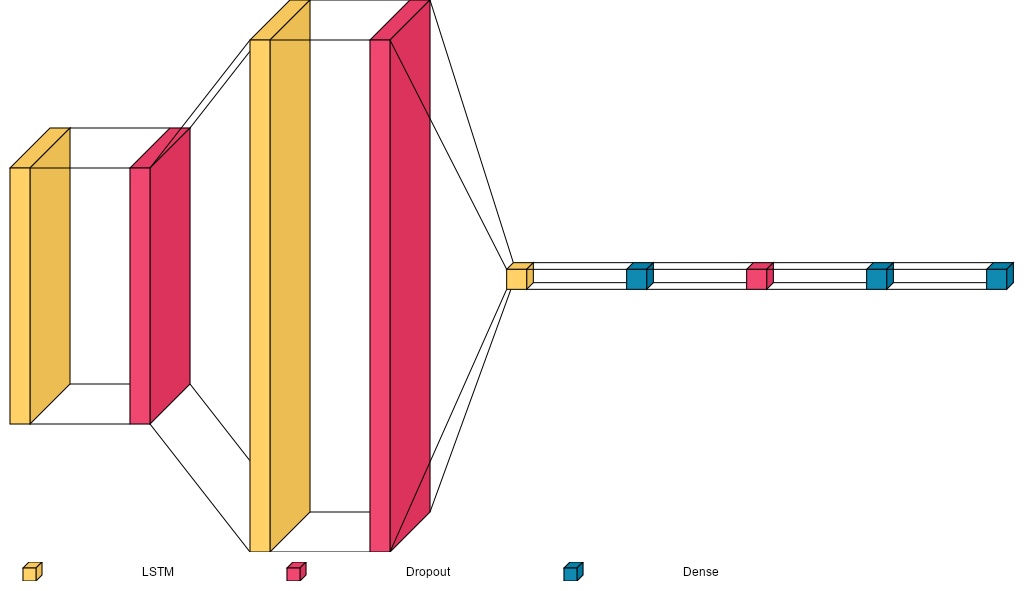

In [34]:
import visualkeras
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12)
visualkeras.layered_view(model, legend=True, font=font,spacing=100)

In [35]:
res = model.predict(X_test)

4/4 [==============================] - 3s 51ms/step


In [36]:

actions[np.argmax(res[4])]

'iloveyou'

In [37]:
actions[np.argmax(y_test[4])]

'iloveyou'

In [38]:

model.save('./model.h5')
model.save_weights('./model_weights.h5');

c:\Users\navya\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [39]:
import tensorflow as tf
model = tf.keras.models.load_model('model.h5')

In [40]:
model.load_weights('model_weights.h5')

In [41]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [42]:

yhat = model.predict(X_test)

4/4 [==============================] - 1s 25ms/step


In [43]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [44]:
from sklearn.metrics import multilabel_confusion_matrix
multilabel_confusion_matrix(ytrue, yhat)

array([[[75,  9],
        [ 7, 35]],

       [[77,  7],
        [13, 29]],

       [[80,  4],
        [ 0, 42]]], dtype=int64)

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(ytrue, yhat)

0.8412698412698413

In [47]:

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
# 3. Classification Report

print(classification_report(ytrue, yhat, target_names=actions))

              precision    recall  f1-score   support

       hello       0.80      0.83      0.81        42
    iloveyou       0.81      0.69      0.74        42
      thanks       0.91      1.00      0.95        42

    accuracy                           0.84       126
   macro avg       0.84      0.84      0.84       126
weighted avg       0.84      0.84      0.84       126



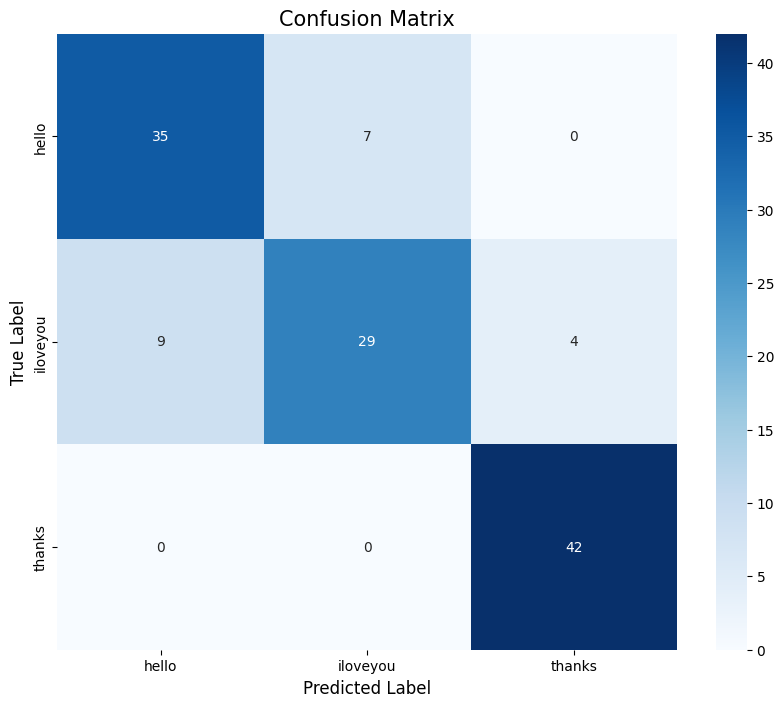

In [49]:
# 4. Confusion Matrix
conf_mat = confusion_matrix(ytrue, yhat)
plt.figure(figsize=(10,8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=actions, yticklabels=actions)
plt.title('Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [51]:
#Class-wise Accuracy
print("\n" + "="*50)
print("CLASS-WISE ACCURACY")
print("="*50)
class_accuracy = 100 * conf_mat.diagonal() / conf_mat.sum(axis=1)
for i, action in enumerate(actions):
    print(f"{action:<10}: {class_accuracy[i]:.2f}%")


CLASS-WISE ACCURACY
hello     : 83.33%
iloveyou  : 69.05%
thanks    : 100.00%


In [53]:
# 5. Additional Metrics
print("\n" + "="*50)
print("ADDITIONAL METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(ytrue, yhat):.2f}")


ADDITIONAL METRICS
Accuracy: 0.84


In [55]:
# 6. Sample Prediction
sample_idx = 4  # You can change this index
print(f"\nSample {sample_idx}:")
print(f"Predicted: {actions[yhat[sample_idx]]}")
print(f"Actual: {actions[ytrue[sample_idx]]}")


Sample 4:
Predicted: iloveyou
Actual: iloveyou


In [56]:
from scipy import stats

In [57]:
colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf

# Define sign actions
actions = np.array(['hello', 'thanks', 'iloveyou'])

# Initialize Mediapipe models
mp_holistic = mp.solutions.holistic  
mp_drawing = mp.solutions.drawing_utils  

# Function for Mediapipe detection
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

# Extract keypoints from Mediapipe results
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

# Load trained model
model = tf.keras.models.load_model('model.h5')
model.load_weights('model_weights.h5')

# Open webcam
cap = cv2.VideoCapture(0)

# Set Mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    sequence = []
    threshold = 0.7  # Increased confidence threshold
    last_prediction = ""
    prediction_timeout = 0

    while cap.isOpened():
        ret, frame = cap.read()
        image, results = mediapipe_detection(frame, holistic)

        # Draw landmarks
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

        # Check if hands are visible
        hands_visible = results.left_hand_landmarks or results.right_hand_landmarks
        
        # Process keypoints only if hands are visible
        if hands_visible:
            keypoints = extract_keypoints(results)
            sequence.append(keypoints)
            sequence = sequence[-30:]  # Maintain sequence length
            
            # Make prediction when we have enough frames
            if len(sequence) == 30:
                res = model.predict(np.expand_dims(sequence, axis=0))[0]
                if res[np.argmax(res)] > threshold:
                    last_prediction = actions[np.argmax(res)]
                    prediction_timeout = 15  # Show prediction for 15 frames after hands disappear
        else:
            if prediction_timeout > 0:
                prediction_timeout -= 1
            else:
                last_prediction = ""

        # Display prediction if available
        if last_prediction:
            cv2.rectangle(image, (0, 0), (640, 40), (245, 117, 16), -1)
            cv2.putText(image, last_prediction, (10, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

        cv2.imshow('Sign Language Recognition', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()



1/1 [==============================] - 0s 27ms/step


In [66]:
import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf

# Define sign actions
actions = np.array(['hello', 'thanks', 'iloveyou'])

# Initialize Mediapipe models
mp_holistic = mp.solutions.holistic  
mp_drawing = mp.solutions.drawing_utils  

# Function for Mediapipe detection
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

# Extract keypoints from Mediapipe results
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

# Load trained model
model = tf.keras.models.load_model('model.h5')
model.load_weights('model_weights.h5')

# Open webcam
cap = cv2.VideoCapture(0)

# Set Mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    sequence = []
    threshold = 0.5

    while cap.isOpened():
        ret, frame = cap.read()
        image, results = mediapipe_detection(frame, holistic)

        # Draw landmarks
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

        # Process keypoints
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]

        # Make prediction
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            predicted_word = actions[np.argmax(res)] if res[np.argmax(res)] > threshold else ""

            # Display only the current predicted word
            cv2.rectangle(image, (0, 0), (640, 40), (245, 117, 16), -1)
            cv2.putText(image, predicted_word, (10, 30), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

        cv2.imshow('Sign Language Recognition', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


1/1 [==============================] - 0s 32ms/step
